In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import sys
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set(style="whitegrid")

In [6]:

raw_df = pd.read_csv('/content/drive/MyDrive/race_rc_project/data/raw/train.csv')

# 80% Train, 10% Val, 10% Test
train_df, temp_df = train_test_split(raw_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 70292
Val size:   8787
Test size:  8787


In [7]:
def data_overview(df: pd.DataFrame, name: str):
    print(f"\n{'='*70}")
    print(f"DATA OVERVIEW — {name}")
    print(f"{'='*70}")
    print(f"Shape           : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Columns         : {list(df.columns)}")
    print(f"\nColumn Types:")
    for col in df.columns:
        print(f"  {col:<20} {str(df[col].dtype):<12} (unique: {df[col].nunique()})")
    print(f"\nMemory Usage    : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

data_overview(train_df, "Train")
data_overview(val_df, "Validation")
data_overview(test_df, "Test")


DATA OVERVIEW — Train
Shape           : 70292 rows × 9 columns
Columns         : ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

Column Types:
  Unnamed: 0           int64        (unique: 70292)
  id                   object       (unique: 24820)
  article              object       (unique: 24820)
  question             object       (unique: 58518)
  A                    object       (unique: 62354)
  B                    object       (unique: 62868)
  C                    object       (unique: 63195)
  D                    object       (unique: 63066)
  answer               object       (unique: 4)

Memory Usage    : 144.9 MB

DATA OVERVIEW — Validation
Shape           : 8787 rows × 9 columns
Columns         : ['Unnamed: 0', 'id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']

Column Types:
  Unnamed: 0           int64        (unique: 8787)
  id                   object       (unique: 7650)
  article              object       (unique: 7650)
  questio

In [8]:
def missing_value_analysis(df: pd.DataFrame, name: str):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    print(f"\n{'='*70}")
    print(f"MISSING VALUES — {name}")
    print(f"{'='*70}")
    print(f"{'Column':<20} {'Missing':<10} {'Percent':<10}")
    print("-"*40)
    for col in df.columns:
        m = missing[col]
        p = missing_pct[col]
        print(f"{col:<20} {m:<10} {p:<10}")

missing_value_analysis(train_df, "Train")


MISSING VALUES — Train
Column               Missing    Percent   
----------------------------------------
Unnamed: 0           0          0.0       
id                   0          0.0       
article              0          0.0       
question             0          0.0       
A                    3          0.0       
B                    0          0.0       
C                    1          0.0       
D                    9          0.01      
answer               0          0.0       


In [9]:
def statistical_summary(df: pd.DataFrame, name: str):
    df = df.copy()
    df['article_len']  = df['article'].astype(str).apply(len)
    df['question_len'] = df['question'].astype(str).apply(len)
    df['avg_option_len'] = (df['A'].astype(str).apply(len) +
                            df['B'].astype(str).apply(len) +
                            df['C'].astype(str).apply(len) +
                            df['D'].astype(str).apply(len)) / 4

    cols = ['article_len', 'question_len', 'avg_option_len']
    print(f"\n{'='*70}")
    print(f"STATISTICAL SUMMARY — {name}")
    print(f"{'='*70}")
    display(df[cols].describe())
    return df

train_df_stats = statistical_summary(train_df, "Train")


STATISTICAL SUMMARY — Train


,article_len,question_len,avg_option_len
count,70292.000000,70292.000000,70292.000000
mean,1558.609671,52.632248,31.932108
std,576.887986,18.917223,17.958860
min,9.000000,1.000000,1.000000
25%,1197.000000,39.000000,17.250000
50%,1588.000000,50.000000,31.250000
75%,1881.000000,63.000000,44.250000
max,6437.000000,380.000000,362.250000


In [10]:
def outlier_detection(df: pd.DataFrame, name: str):
    article_lens = df['article'].astype(str).apply(len)
    Q1 = article_lens.quantile(0.25)
    Q3 = article_lens.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(article_lens < lower) | (article_lens > upper)]
    print(f"\n{'='*70}")
    print(f"OUTLIER DETECTION — {name}")
    print(f"{'='*70}")
    print(f"Lower bound : {lower:.0f}")
    print(f"Upper bound : {upper:.0f}")
    print(f"Outliers    : {len(outliers)} / {len(df)} ({100*len(outliers)/len(df):.2f}%)")

outlier_detection(train_df, "Train")


OUTLIER DETECTION — Train
Lower bound : 171
Upper bound : 2907
Outliers    : 1414 / 70292 (2.01%)


/tmp/ipykernel_16669/3754683695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='answer', data=df, order=['A', 'B', 'C', 'D'], palette='viridis')


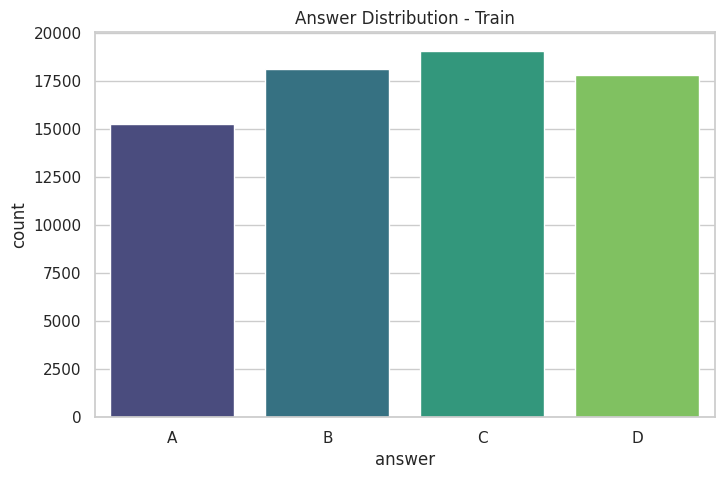

answer
A    21.705173
B    25.808058
C    27.159563
D    25.327207
Name: proportion, dtype: float64


In [15]:
def answer_distribution(df: pd.DataFrame, name: str):
    plt.figure(figsize=(8, 5))
    sns.countplot(x='answer', data=df, order=['A', 'B', 'C', 'D'], palette='viridis')
    plt.title(f'Answer Distribution - {name}')
    plt.show()

    print(df['answer'].value_counts(normalize=True).sort_index() * 100)

answer_distribution(train_df, "Train")

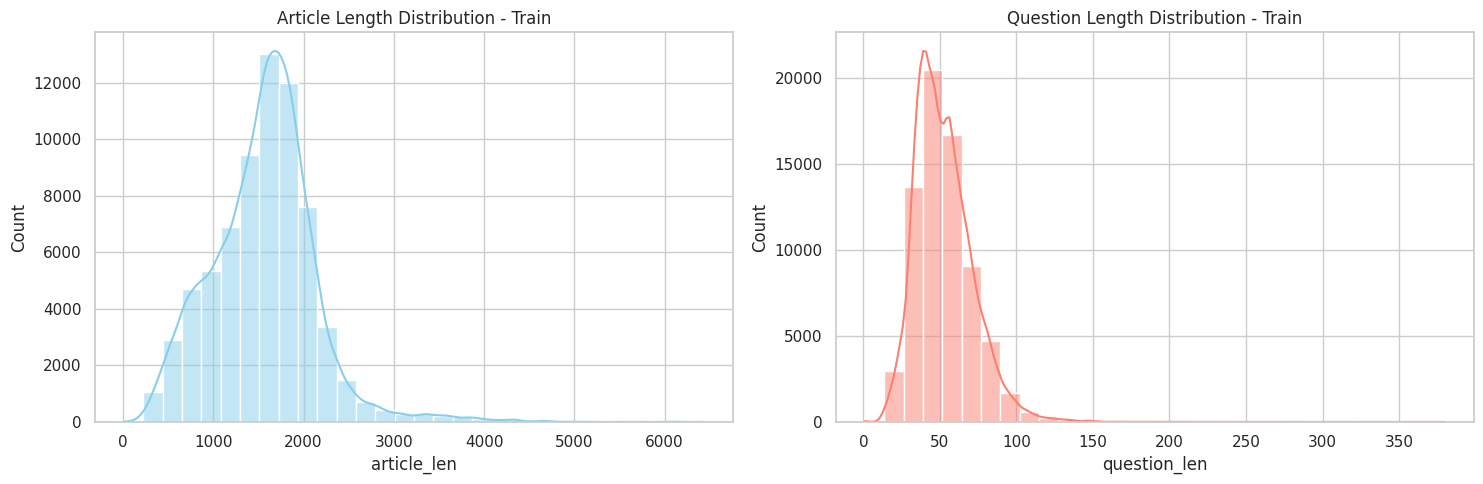

In [12]:
def plot_distributions(df: pd.DataFrame, name: str):
    df = df.copy()
    df['article_len'] = df['article'].astype(str).apply(len)
    df['question_len'] = df['question'].astype(str).apply(len)

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df['article_len'], bins=30, ax=ax[0], color='skyblue', kde=True)
    ax[0].set_title(f'Article Length Distribution - {name}')

    sns.histplot(df['question_len'], bins=30, ax=ax[1], color='salmon', kde=True)
    ax[1].set_title(f'Question Length Distribution - {name}')

    plt.tight_layout()
    plt.show()

plot_distributions(train_df, "Train")

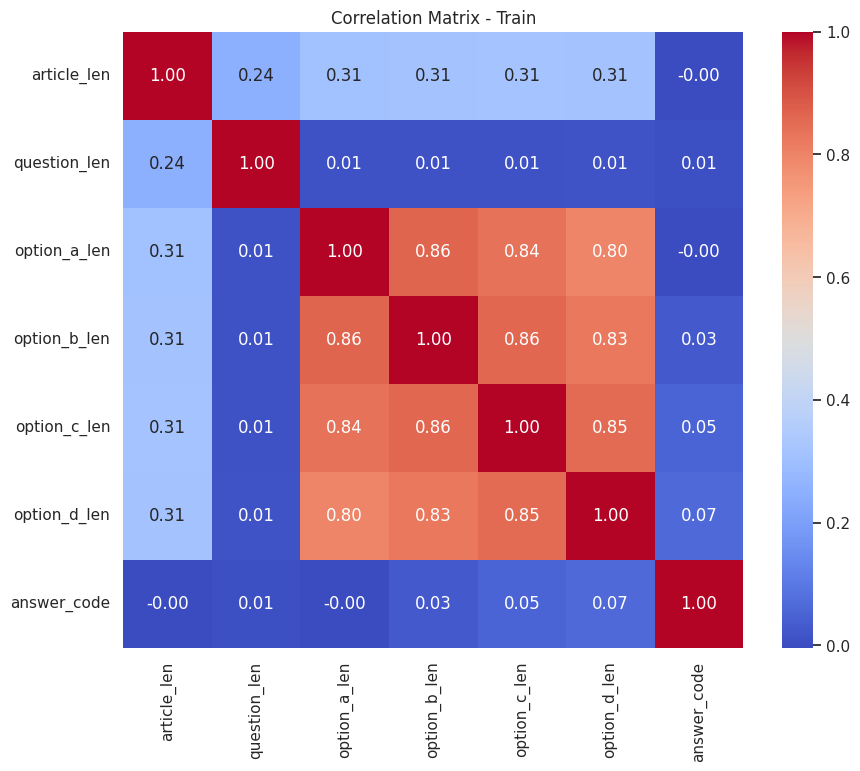

In [13]:
def correlation_analysis(df: pd.DataFrame, name: str):
    df = df.copy()
    df['article_len']  = df['article'].astype(str).apply(len)
    df['question_len'] = df['question'].astype(str).apply(len)
    df['option_a_len'] = df['A'].astype(str).apply(len)
    df['option_b_len'] = df['B'].astype(str).apply(len)
    df['option_c_len'] = df['C'].astype(str).apply(len)
    df['option_d_len'] = df['D'].astype(str).apply(len)
    df['answer_code']  = df['answer'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3})

    cols = ['article_len', 'question_len', 'option_a_len', 'option_b_len',
            'option_c_len', 'option_d_len', 'answer_code']

    corr = df[cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix - {name}')
    plt.show()

correlation_analysis(train_df, "Train")